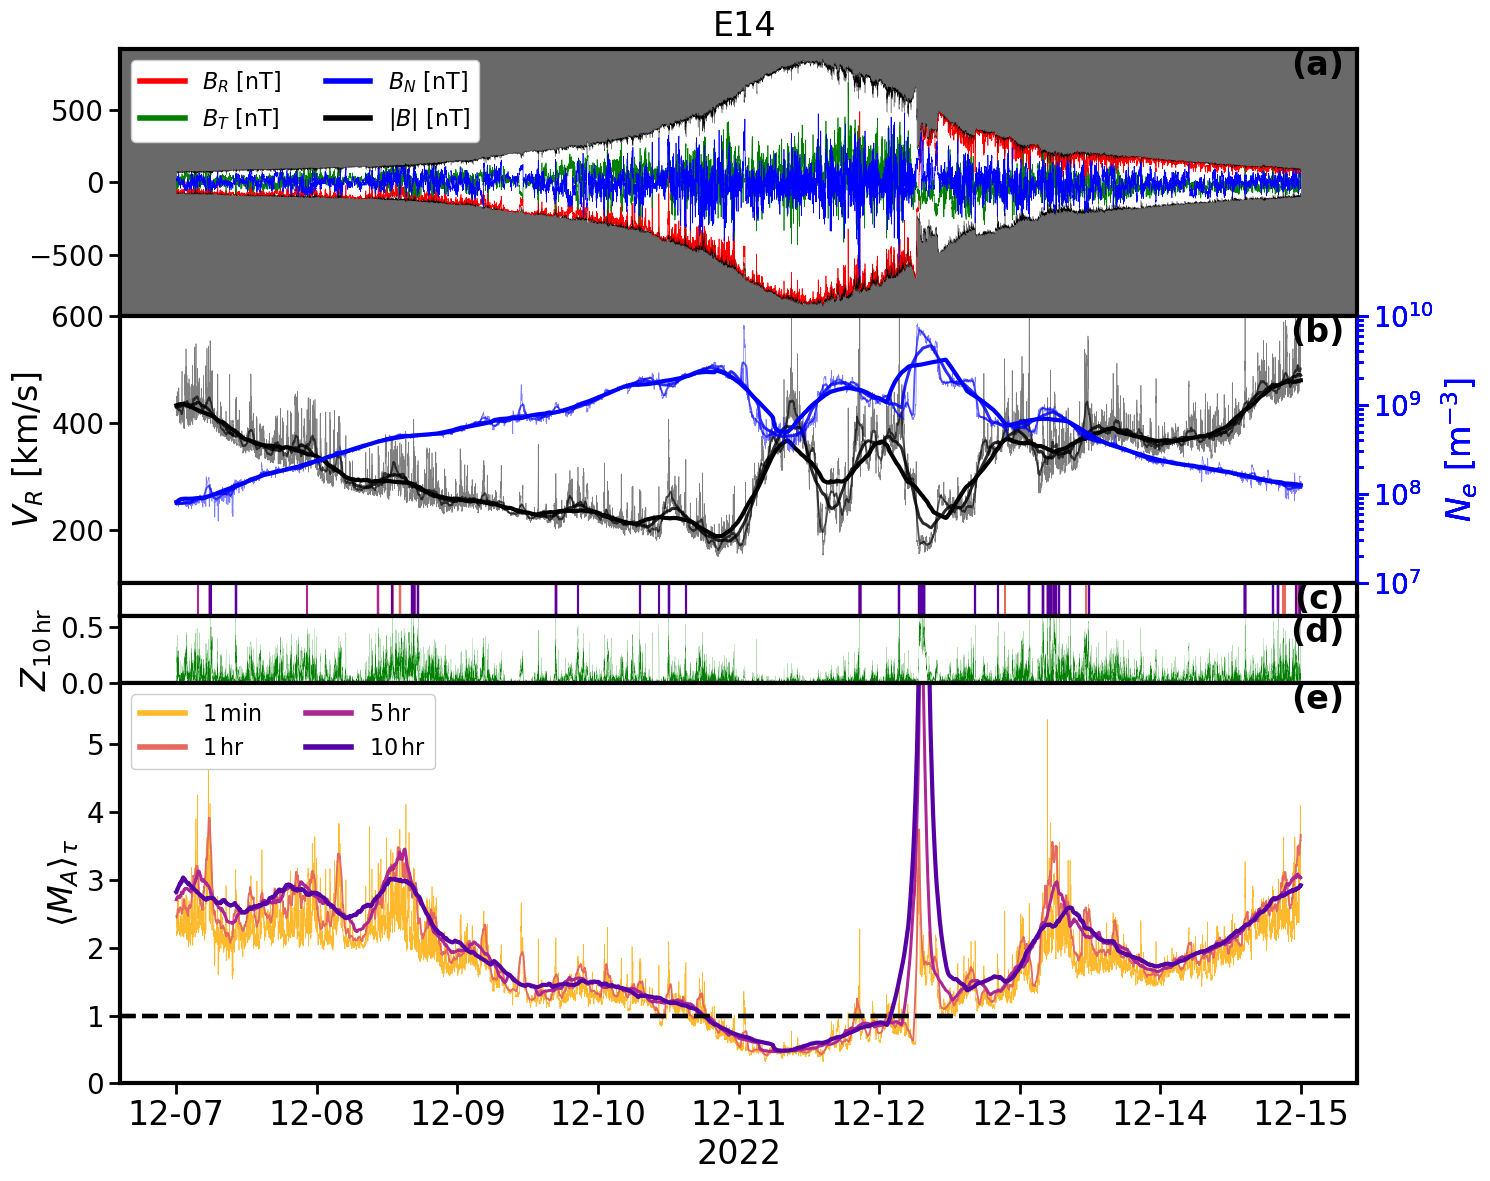

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import importlib
import encs as E
importlib.reload(E)

plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.linewidth': 1.8,
    'axes.labelsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 20,
    "xtick.major.size" : 8,
    "xtick.major.width" : 2,
    "ytick.major.size" : 8,
    "ytick.major.width" :2,
    
    "ytick.minor.size" : 4,
    "ytick.minor.width" :2,
    'legend.fontsize': 16,
    'figure.titlesize': 24
})

ylog = True
xlog = False

ylim = [1e-1, 6e0]
ylim2 = [0, 800]

# enc_range= np.arange(8, 20)


# ax = ax.flat

# cadences = ['60s', '5min', '30min', '1h', '5h', '10h']
# cad_lab = [r'$1\,\rm{min}$', r'$5\,\rm{min}$', r'$30\,\rm{min}$', r'$1\,\rm{h}$', r'$5\,\rm{h}$', r'$10\,\rm{h}$']

cadences = ['1min', '1h', '5h', '10h']
cad_lab = [r'$1\,\rm{min}$', r'$1\,\rm{hr}$', r'$5\,\rm{hr}$', r'$10\,\rm{hr}$']

cmap = plt.get_cmap('plasma_r')  # or 'plasma', 'magma', 'cividis', 'turbo'
vals = np.linspace(0.15, 0.85, len(cadences))

colors = {
    cadence: cmap(v)
    for cadence, v in zip(cadences, vals)
}

lws = np.linspace(0.5, 3, len(cadences))
alpha = np.linspace(0.5, 1, len(cadences))

# lws = np.linspace(0.1, 1, len(cad))

# cols = ['blue', 'red']
# cols = ['blue', 'green', 'black', 'purple', 'brown', 'red']

# df_all = E.load_all_encounters(enc_range).dropna()
dt = 10  # seconds

# cadence_to_points = {
#     '60s': 60 // dt,
#     '5min': 5 * 60 // dt,
#     '30min': 30 * 60 // dt,
#     '1h': 60 * 60 // dt,
#     '5h': 5 * 60 * 60 // dt,
#     '10h': 10 * 60 * 60 // dt,
# }
encs = [14]
# encs = np.arange(8,20)
for enc_range in encs:
    fig, axs = plt.subplots(5, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [4, 4,  0.5, 1, 6], 'hspace': 0}, layout='tight', sharex=True)
    fig.subplots_adjust(hspace=0)
    for cadence, lab, a, lw, c in zip(cadences, cad_lab, alpha, lws, colors.keys()):

        df_enc = E.load_all_encounters([enc_range], res=10).dropna()
        # npts = cadence_to_points[cadence]
        df_enc = df_enc[(df_enc['n'] > 0) & (df_enc['n'] < 1e15)]
        df_10s = df_enc
        df_enc['VA'] = E.VA(df_enc, avg_win= cadence).dropna()
        df_enc = df_enc.rolling(cadence, center = True).mean()
        df_enc['MA'] = E.M_A(df_enc).dropna()
        df_enc['Z'] =  E.Z(df_10s, mean_window = cadence)
        df_enc['Bmag'] = np.sqrt(df_enc['BR']**2 + df_enc['BT']**2 + df_enc['BN']**2)
        df = df_enc
        # df = df_enc[df_enc['encounter'] == enc]
        
        # ax[0].plot(df.index, df['BR'], color= 'tab:brown', alpha = a, lw = lw)
        
        # ax[0].axhline(0, c = 'black', lw = 3, ls = 'dashed')
        
        ax = axs[0]
        if cadence == '1min':
            ylim = 1.08 * np.nanmax(df['Bmag'])
            ax.set_ylim(-ylim, ylim)
            ax.set_facecolor('dimgray')
            
            
            ax.fill_between(
            df.index, -df['Bmag'], df['Bmag'],
            color="white", alpha = 1,
            zorder=0, edgecolors = 'black', lw = 0.1
            )
            
            br, = ax.plot(df.index, df['BR'], color= 'red', lw = lw, alpha = 1)
            
            bt, = ax.plot(df.index, df['BT'], color= 'green', lw = lw, alpha = 1)
            
            bn, = ax.plot(df.index, df['BN'], color= 'blue', lw = lw, alpha = 1)
            bmag, = ax.plot(df.index, df['Bmag'], color= 'black', lw = 0.1, alpha = 1)
            bmag, = ax.plot(df.index, -df['Bmag'], color= 'black', lw = 0.1, alpha = 1)
            
            
            br.set_label(r"$B_R \ [\rm{nT}]$")
            bt.set_label(r"$B_T \ [\rm{nT}]$")
            bn.set_label(r"$B_N \ [\rm{nT}]$")
            bmag.set_label(r"$|B| \ [\rm{nT}]$")
            
            leg = ax.legend(loc = 'upper left', framealpha = 1, ncols = 2)
            for handle in leg.legend_handles:
                handle.set_linewidth(4)
        
        ax = axs[1]
        
        vr, = ax.plot(df.index, df['VR'], color= 'black', lw = lw, alpha = a)
        ax.set_ylim(100, 600)
        ax2 = ax.twinx()
        ax2.spines['right'].set_color('blue')
        n, = ax2.plot(df.index, df['n'], color= 'blue', lw = lw, alpha = a)
        ax2.tick_params(which= 'both', axis='y', colors='blue')
        
        ax2.set_ylim(1e7, 1e10)
        ax2.set_yscale('log')
        
        ax.set_ylabel(r'$V_R \ [\rm{km/s}]$')
        ax2.set_ylabel(r'$N_e \ [\rm{m^{-3}}]$', color = 'blue')
        
        
        ax = axs[2]
        
        ax.vlines(df[(df['Z'] > 0.5)].index, ymin=0,ymax=1,transform=ax.get_xaxis_transform(), color = colors[cadence], zorder = 3, alpha = 1)
        ax.set_yticks([])
        
        ax = axs[3]
        if cadence == '10h':
            ax.plot(df.index, df['Z'], color= 'green', label=rf'{lab}', lw = 0.1, alpha = 1)
            
        

        ax.set_yticks([0, 0.5])
        ax.set_ylabel(r'$Z_{10 \, \rm{hr}}$')
        
        # print(len(df[(df['Z'] > 0.5)]))
        # ax.axhline(0.5, c = 'blue', lw = 3, ls = 'dashed')
        ax.set_ylim(0, 0.6)
        

        
        ax = axs[4]
        
        ax.plot(df.index, df['MA'], color= colors[cadence], label=rf'{lab}', alpha = 1, lw = lw)
            

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.set_xlabel(df.index[0].year)
        

            
        # ax.vlines(df[(df['Z'] > 0.5)].index, ymin=0,ymax=1,transform=ax.get_xaxis_transform(), color = 'black', zorder = 3)


            # if idx % 3 == 0: 
        ax.set_ylabel(r'$\langle M_A \rangle_{\tau}$')
            # if ylog == True:
            #     ax.set_yscale('log')
        leg = ax.legend(loc = 'upper left', framealpha = 1, ncols = 2)  
        for handle in leg.legend_handles:
                handle.set_linewidth(4)
        ax.axhline(1, c = 'black', lw = 3, ls = 'dashed')

        ax.set_ylim(0,5.9)
        # ax[1].set_ylim(ylim2[0],ylim2[1])
        # ax2.set_ylim(ylim2[0],ylim2[1])
        
    for a in axs:
        for spine in a.spines.values():
            spine.set_linewidth(3)    
            
labels = ["(a)", "(b)", "(c)", "(d)", '(e)',]

for a, label in zip(axs, labels):
    a.text(
        0.99, 1.00, label,
        transform=a.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="right"
    )
    fig.suptitle(f'E{enc_range}')
    fig.savefig(f'fig/MA_enc{enc_range}.png', dpi = 500)
    fig.show()
    # plt.close()
    


In [2]:
enc_range = 14
cadences = ['1min', '1h', '5h', '10h']
for cadence in cadences:
    df_enc = E.load_all_encounters([enc_range], res=10).dropna()
    # npts = cadence_to_points[cadence]
    df_enc = df_enc[(df_enc['n'] > 0) & (df_enc['n'] < 1e15)]
    df_10s = df_enc
    # df_enc['n'] = df_enc['n'].interpolate(method = 'linear')
    df_enc = df_enc.rolling(cadence, center = True).mean()
    df_enc['VA'] = E.VA(df_enc).dropna()
    df_enc['MA'] = E.M_A(df_enc).dropna()
    df_enc['Z'] =  E.Z(df_10s, mean_window = cadence)
    df = df_enc

    mask = df["Z"] > 0.5

    total_duration = mask.sum() * pd.Timedelta(seconds=10)
    print(total_duration)

0 days 00:00:00
0 days 00:17:30
0 days 00:32:20
0 days 00:47:40


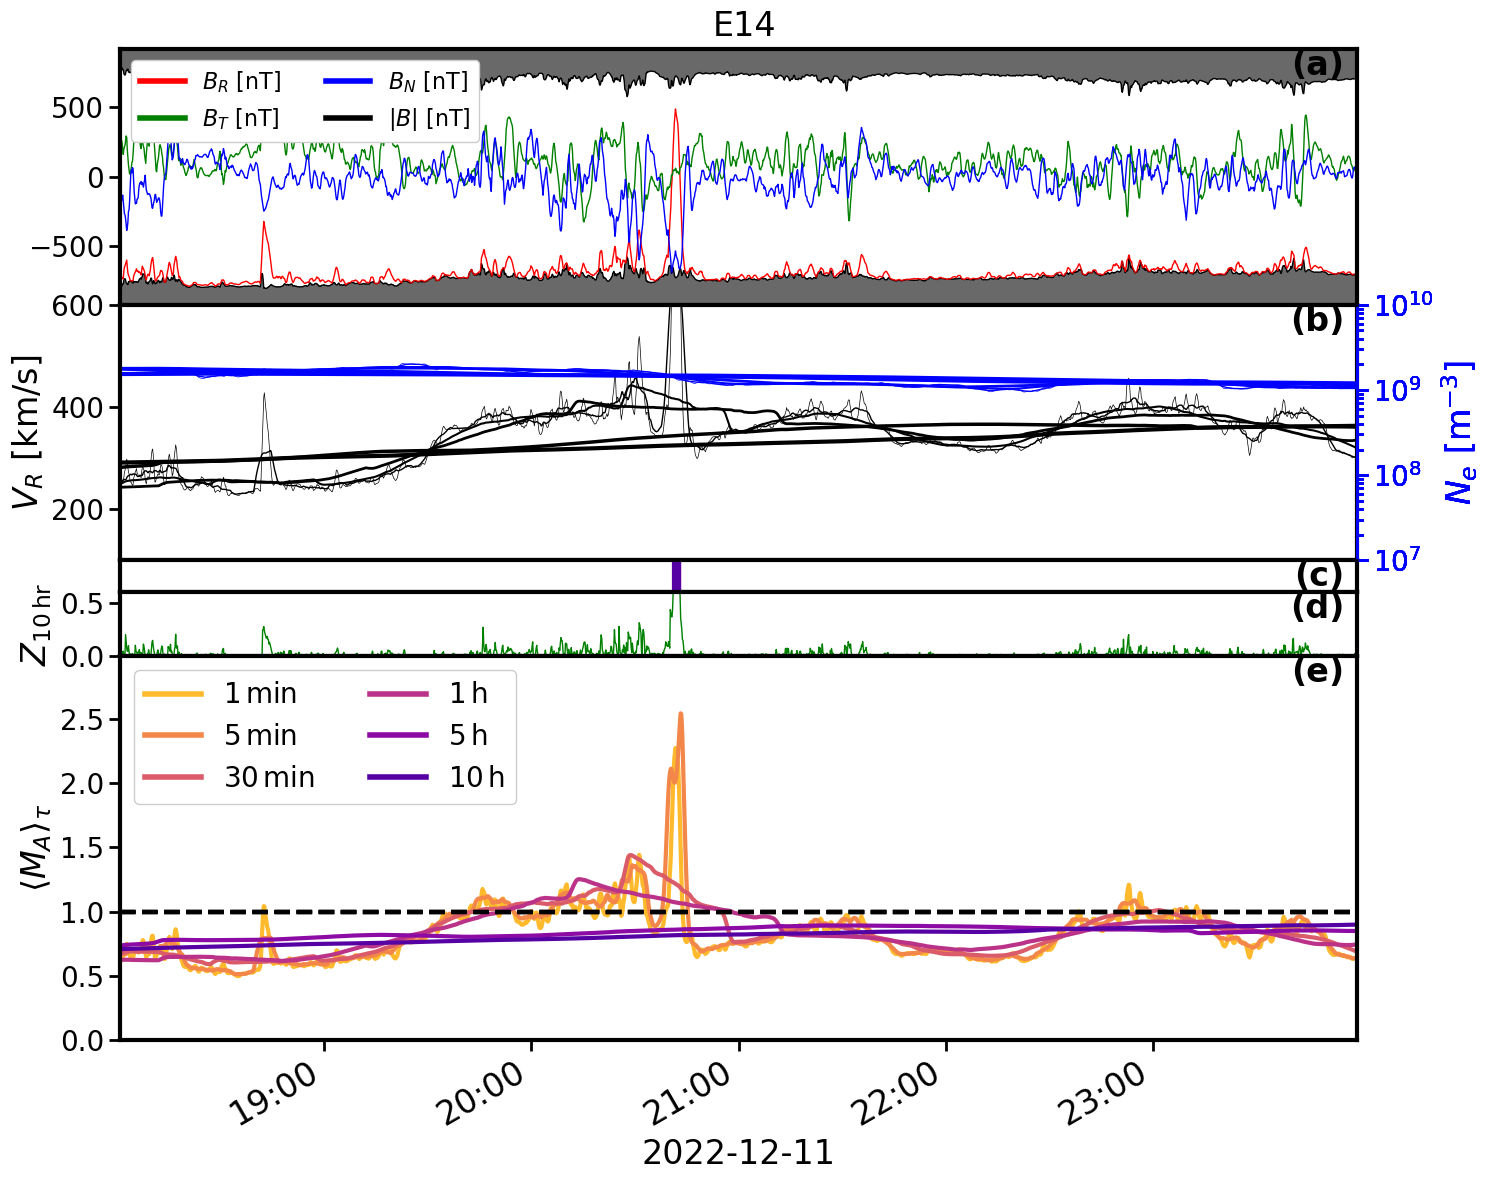

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import importlib
import encs as E
importlib.reload(E)

plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.linewidth': 1.8,
    'axes.labelsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 20,
    "xtick.major.size" : 8,
    "xtick.major.width" : 2,
    "ytick.major.size" : 8,
    "ytick.major.width" :2,
    
    "ytick.minor.size" : 4,
    "ytick.minor.width" :2,
    'legend.fontsize': 16,
    'figure.titlesize': 24
})

ylog = True
xlog = False

ylim = [1e-1, 6e0]
ylim2 = [0, 800]

# enc_range= np.arange(8, 20)


# ax = ax.flat

cadences = ['1min', '5min', '30min', '1h', '5h', '10h']
cad_lab = [r'$1\,\rm{min}$', r'$5\,\rm{min}$', r'$30\,\rm{min}$', r'$1\,\rm{h}$', r'$5\,\rm{h}$', r'$10\,\rm{h}$']

# cadences = ['1min', '1h', '5h', '10h']
# cad_lab = [r'$1\,\rm{min}$', r'$1\,\rm{hr}$', r'$5\,\rm{hr}$', r'$10\,\rm{hr}$']

cmap = plt.get_cmap('plasma_r')  # or 'plasma', 'magma', 'cividis', 'turbo'
vals = np.linspace(0.15, 0.85, len(cadences))

colors = {
    cadence: cmap(v)
    for cadence, v in zip(cadences, vals)
}

lws = np.linspace(0.5, 3, len(cadences))
alpha = np.linspace(0.5, 1, len(cadences))

# lws = np.linspace(0.1, 1, len(cad))

# cols = ['blue', 'red']
# cols = ['blue', 'green', 'black', 'purple', 'brown', 'red']

# df_all = E.load_all_encounters(enc_range).dropna()
dt = 10  # seconds

# cadence_to_points = {
#     '60s': 60 // dt,
#     '5min': 5 * 60 // dt,
#     '30min': 30 * 60 // dt,
#     '1h': 60 * 60 // dt,
#     '5h': 5 * 60 * 60 // dt,
#     '10h': 10 * 60 * 60 // dt,
# }
encs = [14]
# encs = np.arange(8,20)
for enc_range in encs:
    fig, axs = plt.subplots(5, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [4, 4,  0.5, 1, 6], 'hspace': 0.0}, layout='tight', sharex=True)
    fig.subplots_adjust(hspace=0)
    for cadence, lab, a, lw, c in zip(cadences, cad_lab, alpha, lws, colors.keys()):

        df_enc = E.load_all_encounters([enc_range], res=10).dropna()
        # npts = cadence_to_points[cadence]
        df_enc = df_enc[(df_enc['n'] > 0) & (df_enc['n'] < 1e15)]
        df_10s = df_enc
        df_enc = df_enc.rolling(cadence, center = True).mean()
        df_enc['VA'] = E.VA(df_enc).dropna()
        df_enc['MA'] = E.M_A(df_enc).dropna()
        df_enc['Z'] =  E.Z(df_10s, mean_window = cadence)
        df_enc['Bmag'] = np.sqrt(df_enc['BR']**2 + df_enc['BT']**2 + df_enc['BN']**2)
        df = df_enc
        # df = df_enc[df_enc['encounter'] == enc]
        
        # ax[0].plot(df.index, df['BR'], color= 'tab:brown', alpha = a, lw = lw)
        
        # ax[0].axhline(0, c = 'black', lw = 3, ls = 'dashed')
        
        ax = axs[0]
        if cadence == '1min':
            ylim = 1.08 * np.nanmax(df['Bmag'])
            ax.set_ylim(-ylim, ylim)
            ax.set_facecolor('dimgray')
            
            
            ax.fill_between(
            df.index, -df['Bmag'], df['Bmag'],
            color="white", alpha = 1,
            zorder=0, edgecolors = 'black', lw = 1
            )
            
            br, = ax.plot(df.index, df['BR'], color= 'red', lw = 1, alpha = 1)
            
            bt, = ax.plot(df.index, df['BT'], color= 'green', lw = 1, alpha = 1)
            
            bn, = ax.plot(df.index, df['BN'], color= 'blue', lw = 1, alpha = 1)
            bmag, = ax.plot(df.index, df['Bmag'], color= 'black', lw = 0.1, alpha = 1)
            bmag, = ax.plot(df.index, -df['Bmag'], color= 'black', lw = 0.1, alpha = 1)
            
            br.set_label(r"$B_R \ [\rm{nT}]$")
            bt.set_label(r"$B_T \ [\rm{nT}]$")
            bn.set_label(r"$B_N \ [\rm{nT}]$")
            bmag.set_label(r"$|B| \ [\rm{nT}]$")

            leg = ax.legend(loc = 'upper left', framealpha = 1, ncols = 2)
            for handle in leg.legend_handles:
                handle.set_linewidth(4)
        
        ax = axs[1]
        
        vr, = ax.plot(df.index, df['VR'], color= 'black', lw = lw, alpha = 1)
        ax.set_ylim(100, 600)
        ax2 = ax.twinx()
        ax2.spines['right'].set_color('blue')
        n, = ax2.plot(df.index, df['n'], color= 'blue', lw = lw, alpha = 1)
        ax2.tick_params(which= 'both', axis='y', colors='blue')
        
        ax2.set_ylim(1e7, 1e10)
        ax2.set_yscale('log')
        
        ax.set_ylabel(r'$V_R \ [\rm{km/s}]$')
        ax2.set_ylabel(r'$N_e \ [\rm{m^{-3}}]$', color = 'blue')
        
        
        ax = axs[2]
        
        ax.vlines(df[(df['Z'] > 0.5)].index, ymin=0,ymax=1,transform=ax.get_xaxis_transform(), color = colors[cadence], zorder = 3, alpha = 1)
        ax.set_yticks([])
        
        ax = axs[3]
        if cadence == '10h':
            ax.plot(df.index, df['Z'], color= 'green', label=rf'{lab}', lw = 1, alpha = 1)
            
        

        ax.set_yticks([0, 0.5])
        ax.set_ylabel(r'$Z_{10 \, \rm{hr}}$')
        
        # print(len(df[(df['Z'] > 0.5)]))
        # ax.axhline(0.5, c = 'blue', lw = 3, ls = 'dashed')
        ax.set_ylim(0, 0.6)
        

        
        ax = axs[4]
        
        ax.plot(df.index, df['MA'], color= colors[cadence], label=rf'{lab}', alpha = 1, lw = 3)
            

        # ax.set_xlabel(mdates.DateFormatter('%m-%d %H:%M'))
        

            
        # ax.vlines(df[(df['Z'] > 0.5)].index, ymin=0,ymax=1,transform=ax.get_xaxis_transform(), color = 'black', zorder = 3)


            # if idx % 3 == 0: 
        ax.set_ylabel(r'$\langle M_A \rangle_{\tau}$')
            # if ylog == True:
            #     ax.set_yscale('log')
        leg = ax.legend(loc = 'upper left',fontsize = 20, framealpha = 1, ncols = 2)  
        for handle in leg.legend_handles:
                handle.set_linewidth(4)
        ax.axhline(1, c = 'black', lw = 3, ls = 'dashed')
        ax.set_ylim(0,2.99)

st = pd.Timestamp("2022-12-11 18:01:00")
end = pd.Timestamp("2022-12-11 23:59:00")

# Format the x-axis to show Month-Day Hour:Minute
date_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(date_format)
ax.set_xlabel(pd.Timestamp("2022-12-11 18:01:00").date())

plt.gcf().autofmt_xdate() 

ax.set_xlim(st, end)
        # ax[1].set_ylim(ylim2[0],ylim2[1])
        # ax2.set_ylim(ylim2[0],ylim2[1])
        
for a in axs:
    for spine in a.spines.values():
        spine.set_linewidth(3)    

labels = ["(a)", "(b)", "(c)", "(d)", '(e)',]

for a, label in zip(axs, labels):
    a.text(
        0.99, 1.00, label,
        transform=a.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="right"
    )

fig.suptitle(f'E{enc_range}')
fig.savefig(f'fig/MA_enc{enc_range}_zoom.png', dpi = 500)
fig.show()
    # plt.close()
    
